In [36]:
# Import necessary libraries and modules
from Tracer import Trajectory, WindField, Fluctuator

# Creating instances

In [37]:
# if you want to use the RANS data, make sure to provide the correct path to the nc file
file = '../RANS/nc files/flowdata_2m_cartesian.nc' # example file
wind_rans = WindField(profile='rans', ds=file)

# Or you can use the log profile, which is a simple analytical model for the wind speed as a function of height
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=45)

fluc = Fluctuator(method='Langevin', dt=0.01, C0=2.1, cf=1.0)

# Create a trajectory with the given parameters
traj = Trajectory(
    ball_speed=76, 
    launch_angle=13, 
    spin_rate=2500,
    wind=wind,
    fluc=fluc
    )

Synthesizing wind field with parameters: z_height=100, direction=45, U_ref=8, z0=0.03, z_ref=10


# Solving trajectories

In [38]:
print("solve status:", traj.is_solved, "\n"+"="*20)

# solve it using the Runge-Kutta or Euler method
traj.solve('euler')
print(traj, "\n"+"="*20)
traj.solve('rk45')
print(traj, "\n"+"="*20)

print("solve status:", traj.is_solved)

solve status: False 
Trajectory(ball_speed=76, launch_angle=13, spin_rate=2500, spin_axis=0) 
V0=[74.05  0.   17.1 ], 
W0=[   0.  -261.8    0. ], 
P0=[0 0 0], 
Final Position=[ 2.7231e+02  2.0460e+01 -7.0000e-02], 
 Time=7.24 s 


KeyboardInterrupt: 

# Rotate settings

In [ ]:
# Either create a new trajectory with the desired orientation, 
rotated_traj = Trajectory(
    ball_speed=76, 
    launch_angle=13, 
    spin_rate=2500,
    wind=wind,
    orientation=45 # here
    )

# Or rotate an existing trajectory NB: this has to be solved again

rotated_traj = traj.rotate(45) # here

In [ ]:
print(rotated_traj) # see how the values are equal in x and y from rotation

Trajectory(V0=[52.36 52.36 17.1 ], W0=[ 185.12 -185.12    0.  ], P0=[0 0 0])


# Add fluctuations to the wind

In [ ]:
wind = WindField(profile='log', U_ref=8, z_ref=10, z0=0.03, direction=0)

methods = ['Simple', 'Langevin', 'POD']

landing_points = {method: [] for method in methods}

for method in methods:
    for i in range(40):
        fluc = Fluctuator(method=method, dt=0.01, C0=2.1, cf=1.0, n_modes=13) # settings can be adjusted as needed
        traj = Trajectory(
            ball_speed=76, 
            launch_angle=13, 
            spin_rate=2500,
            wind=wind,
            fluc=fluc
        )
        if method == 'POD':
            traj.solve('rk45')
        else:
            traj.solve('euler')
        landing_points[method].append(traj.p[-1][:2])


Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=8, z0=0.03, z_ref=10


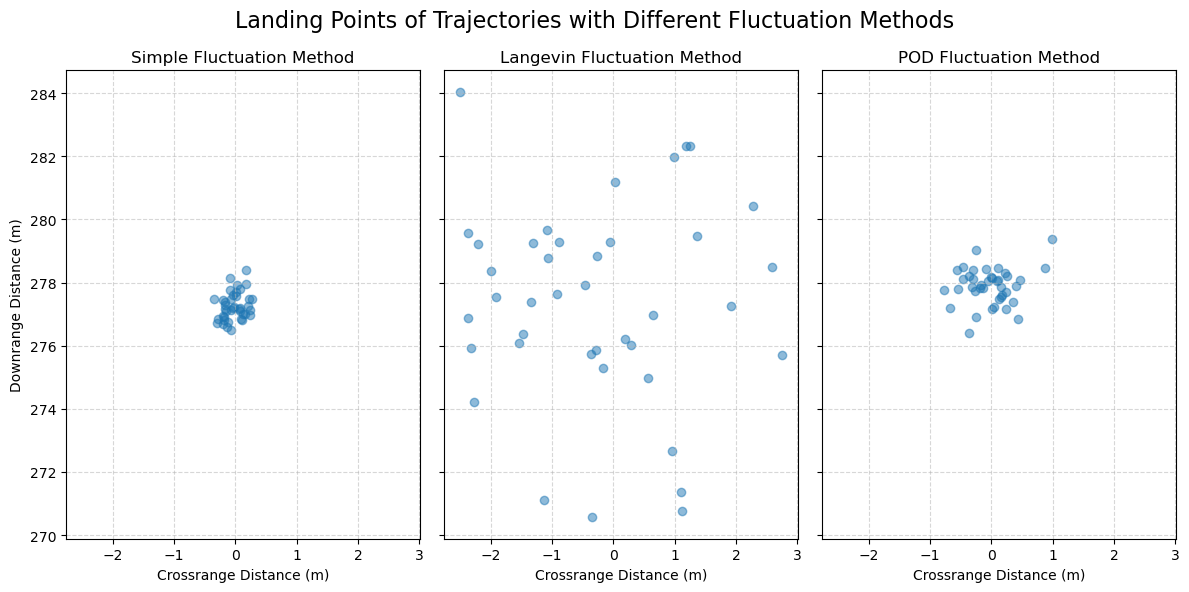

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(1,3,figsize=(12, 6), sharey=True, sharex=True)
for i, method in enumerate(methods):
    points = np.array(landing_points[method])
    axs[i].scatter(points[:, 1], points[:, 0], alpha=0.5)
    axs[i].set_title(f'{method[0].upper() + method[1:]} Fluctuation Method')
    axs[i].set_xlabel('Crossrange Distance (m)')
    axs[i].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0].set_ylabel('Downrange Distance (m)')
plt.suptitle('Landing Points of Trajectories with Different Fluctuation Methods', fontsize=16)
plt.tight_layout()
plt.show()

# Plot and Animate

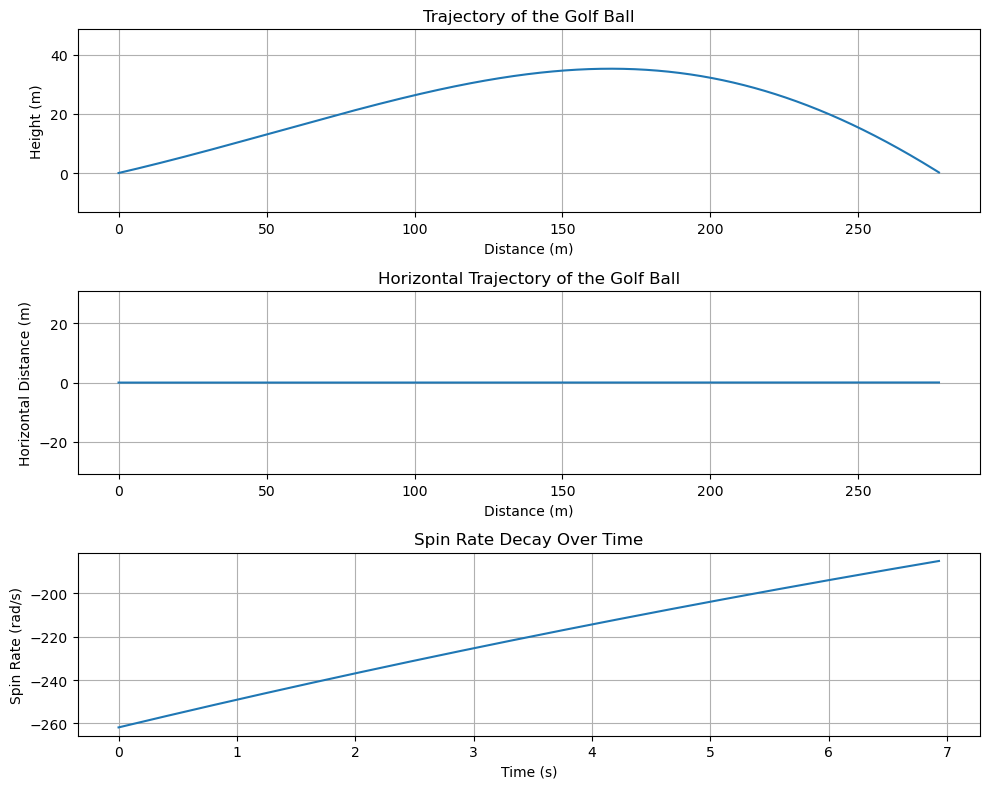

In [ ]:
# debug plot of the trajectory
traj.plot()

In [ ]:
# Animation of the trajectory to inspect the 3D path and the effect of the spin and wind
rotated_traj.animate()